**Pima Indian Diabetes Analysis**

This notebook explores a dataset from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. 

We will perform data cleaning, ompleting missing values,  descriptive statistics, and visualization to understand the distribution of features and their relationship with the target variable (presence or absence of diabetes).

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch 
import kagglehub 
from kagglehub import KaggleDatasetAdapter 
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from scipy.stats import spearmanr
from scipy import stats
import duckdb

In [2]:
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "aminizahra/pima-indians-diabetes", "pima-indians-diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


We could see that our dataset has 767 rows and 9 columns. 
Now column names start with big letter and are to big to refer to tham without any mistake every time. So we will rewrite it lowercase such it how usually name variebles in python and make it shorter so it will be easier to refer to them. 

In [3]:
df = df.rename(columns={
    'Pregnancies': 'preg',
    'Glucose': 'gluco',
    'BloodPressure': 'bp',
    'SkinThickness': 'skin',
    'Insulin': 'insul',
    'BMI': 'bmi',
    'DiabetespedigreeFunction': 'pedig',
    'Age': 'age',
    'Outcome': 'target'
})
df.head()

,preg,gluco,bp,skin,insul,bmi,pedig,age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   gluco   768 non-null    int64  
 2   bp      768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insul   768 non-null    int64  
 5   bmi     768 non-null    float64
 6   pedig   768 non-null    float64
 7   age     768 non-null    int64  
 8   target  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


We could se that we have 6 columns with integer values, and 2 columns with foat, but target column should not be numerical, but categorial. Here 0 and 1 not just nubers it shows as wether patient have diabetis or not. So 0, means patient doesn`t have the disease. 

In [5]:
df["target"] = df["target"].astype("category")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   preg    768 non-null    int64   
 1   gluco   768 non-null    int64   
 2   bp      768 non-null    int64   
 3   skin    768 non-null    int64   
 4   insul   768 non-null    int64   
 5   bmi     768 non-null    float64 
 6   pedig   768 non-null    float64 
 7   age     768 non-null    int64   
 8   target  768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 49.0 KB


In [7]:
df.describe()

,preg,gluco,bp,skin,insul,bmi,pedig,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [8]:
df.duplicated().sum()

np.int64(0)

There`re o duplicates in the dataset

In [9]:
df.isna().sum()


preg      0
gluco     0
bp        0
skin      0
insul     0
bmi       0
pedig     0
age       0
target    0
dtype: int64

We could see that there`re no missing values in the dataset, but from data description we could see that there are "0" values in the columns like glucose or bp what is impossible so that is our missing values. 

In [10]:
cols_with_zeros = ['gluco', 'bp', 'skin', 'insul', 'bmi']

df[cols_with_zeros] = df[cols_with_zeros].replace(0,np.nan)

df.isna().sum()

preg        0
gluco       5
bp         35
skin      227
insul     374
bmi        11
pedig       0
age         0
target      0
dtype: int64

In [11]:
percent_of_absent_data = {}
for col in cols_with_zeros:
    percent_of_absent_data[col] = df[col].isnull().sum()/df[col].count()
print("Persent of mised values for each column:")
for col in percent_of_absent_data.keys():
    print(f"{col} - {int(percent_of_absent_data[col]*100)} percent")

Persent of mised values for each column:
gluco - 0 percent
bp - 4 percent
skin - 41 percent
insul - 94 percent
bmi - 1 percent


For columns with less than 5% of missed data (Glucose, DloodPresure, BMI) we apply group based imputation using the mean/median, segmented by target class to preserve group distributions.

Build a histogram to see how our data spread and what will be more informative for our goal median or mean. 

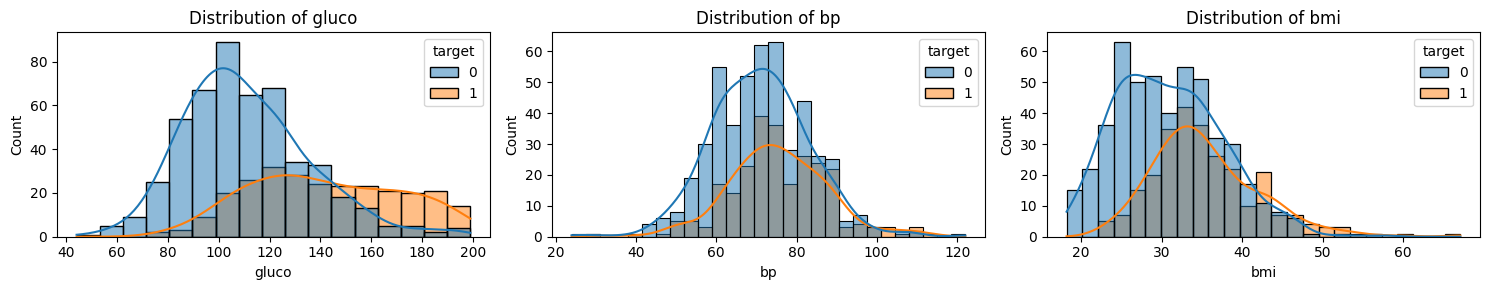

In [12]:
plt.figure(figsize=(15, 3))

cols_to_check = ['gluco', 'bp', 'bmi']
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    # Побудова гістограми з лінією розподілу (KDE)
    sns.histplot(data=df, x=col, hue="target", kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Distribution of glucose and bmi is right squwed, so it will be better to take median insted of a mean.

In [13]:
for col in cols_to_check: 
    df[col] = df[col].fillna(df.groupby("target", observed=False)[col].transform('median'))

In [14]:
for col in cols_to_check: 
    print(f"Check for nulls in {col} column: {df[col].isnull().any()}")

Check for nulls in gluco column: False
Check for nulls in bp column: False
Check for nulls in bmi column: False


In [15]:
df.describe()

,preg,gluco,bp,skin,insul,bmi,pedig,age
count,768.000000,768.000000,768.000000,541.000000,394.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.153420,155.548223,32.434635,0.471876,33.240885
std,3.369578,30.464161,12.106039,10.476982,118.775855,6.880498,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.050000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


We cleaned coluns with less than 5% missed data. 

For columns with more than 5% missed data we will use MICE (Multivariate Imputation by Chained Equations) it will not just replace our nulls with median, but will try to guess what was on the missing spot by the values in another columns. We will predict this values based on all columns, except the target column, as usually we want to predict target value. 

In [16]:
X = df.drop('target', axis=1)
y = df['target']

imputer = IterativeImputer(max_iter=10, random_state=42, estimator=BayesianRidge())

df_imputed = imputer.fit_transform(X)

df_final = pd.DataFrame(df_imputed, columns=X.columns)
df_final["target"] = y.values

In [17]:
df_final.describe()

,preg,gluco,bp,skin,insul,bmi,pedig,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,28.898734,152.619979,32.434635,0.471876,33.240885
std,3.369578,30.464161,12.106039,9.524083,97.403340,6.880498,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,-19.425703,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,22.119807,89.553537,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,28.451616,130.000000,32.050000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,35.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


We could see that after useing iterative imputer we got negative values for insulin, this is impossible, so we would add min values for all the column and try it one more time. As min value we will acsept min value in every column we already got. 

In [18]:
X = df.drop('target', axis=1)
y = df['target']

get_min_auto = lambda col: X[col][X[col] > 0].min() if (X[col] > 0).any() else X[col].min()
all_min_values = {col: get_min_auto(col) for col in X.columns}
min_values_list = [all_min_values[col] for col in X.columns]

imputer = IterativeImputer(max_iter=10, random_state=42, estimator=BayesianRidge(), min_value=min_values_list)

df_imputed = imputer.fit_transform(X)

df_final = pd.DataFrame(df_imputed, columns=X.columns)
df_final["target"] = y.values

In [19]:
df_final.describe()

,preg,gluco,bp,skin,insul,bmi,pedig,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,28.898761,152.663557,32.434635,0.471876,33.240885
std,3.369578,30.464161,12.106039,9.524061,97.333728,6.880498,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,22.119808,89.553537,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,28.451616,130.000000,32.050000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,35.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [20]:
df[col].isnull().any()

np.False_

We sucsefully cleansed all null values in our dataframe. 

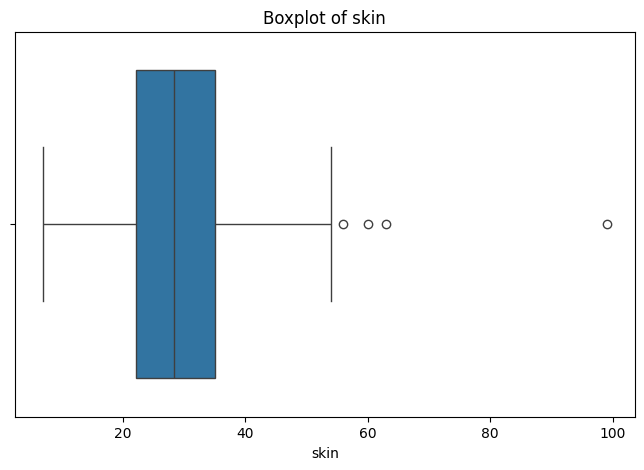

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_final["skin"])
plt.title('Boxplot of skin')
plt.show()

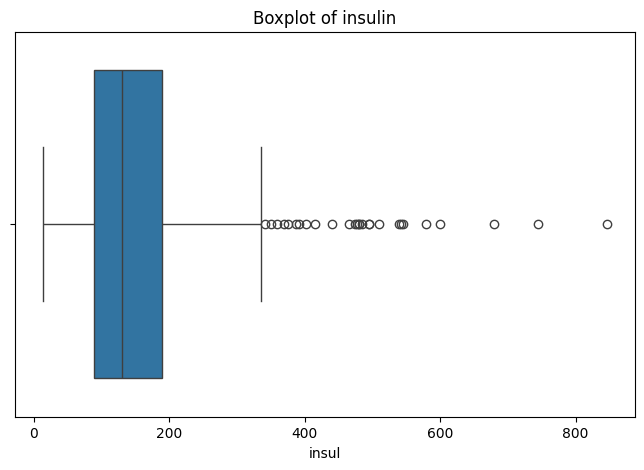

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_final["insul"])
plt.title('Boxplot of insulin')
plt.show()

We could see that both skin and insulin box plots have outliers in the right side, it beacause people with diseases have more intens levels than without them. 

We will not cut the outliers such as this meanings very 

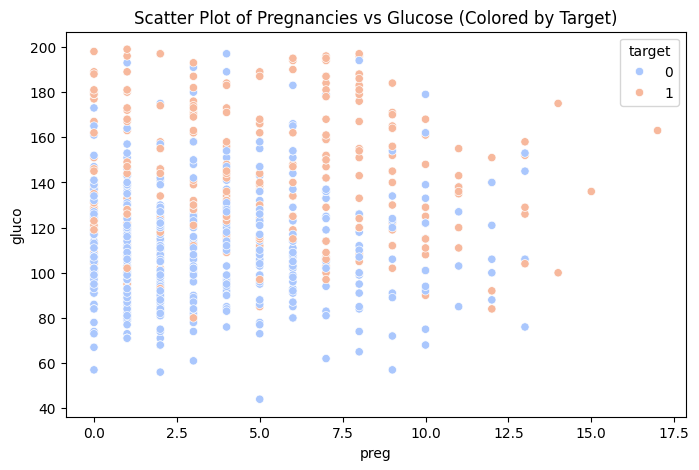

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='preg', y='gluco', data=df_final, hue='target', palette='coolwarm')
plt.title('Scatter Plot of Pregnancies vs Glucose (Colored by Target)')
plt.show()

My Observations on Pregnancies and Glucose
Looking at the scatter plot, I’ve noticed two very interesting things:

Pregnancy as a Risk Factor: There’s a clear pattern where women with more pregnancies have a much higher risk of diabetes, even if their glucose levels look "normal" or low. I think this is related to gestational diabetes. It seems that every pregnancy puts a cumulative strain on the body, making it harder to process sugar in the long run.

The "8+ Pregnancies" Mystery: A very strange thing happens after the 8th pregnancy—the maximum glucose levels actually start to drop. You’d expect the opposite, but the "ceiling" for sugar levels goes down. I have two theories for this:

Social/Economic Reasons: It could be about lifestyle or nutrition. Maybe these women have less access to high-calorie food, or on the contrary, they have better health habits and a stricter diet because they’ve learned how to manage their health over the years.

The "Survivor" Effect: It’s possible that only women with very resilient bodies can have 8 or more children and stay healthy enough to be in this study. Those who had extreme sugar spikes might have faced complications much earlier and simply aren't represented in this high-pregnancy group.

Summary: While more pregnancies definitely increase the risk of diabetes, the drop in maximum glucose for large families is a paradox that shows we need to look closer at how age and lifestyle impact these women.


To look closer for economic reason theory we will build one more scatter plot, based on pregnancies and gluco but now we will color it with bmi, so if this womans are phicically exausted thay will usually have low bmi. 

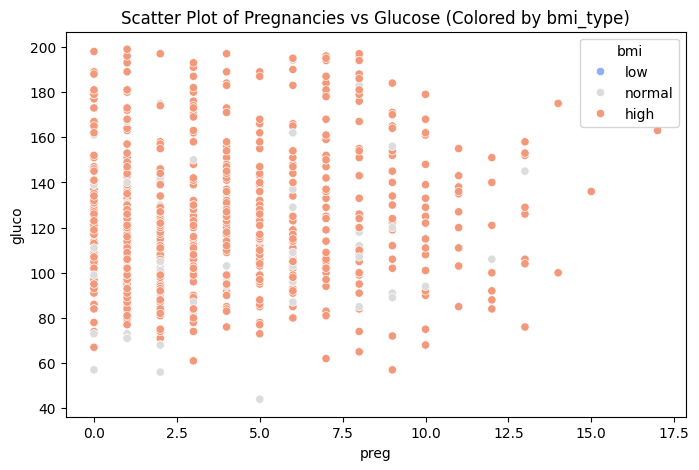

In [24]:
bins = [0, 18.5, 25, df_final['bmi'].max()]
labels = ['low', 'normal', 'high']

bmi_virtual = pd.cut(df_final['bmi'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='preg', y='gluco', data=df_final, hue=bmi_virtual, palette='coolwarm')
plt.title('Scatter Plot of Pregnancies vs Glucose (Colored by bmi_type)')
plt.show()

The analysis shows that the vast majority of the population in this dataset has a BMI above the normal range, with very few individuals falling into the 'Normal' category. There is no clear linear correlation between BMI, pregnancy count, and glucose levels.

This lack of a direct relationship suggests that diabetes risk in this group is not driven by a single factor alone. Instead, it points toward a complex interplay of genetics, lifestyle, and potential socio-economic constraints. The fact that glucose doesn't automatically rise with BMI indicates that some individuals may have metabolic resilience, while others are more vulnerable regardless of their weight

In [25]:
corr, p_value = spearmanr(df_final['preg'], df_final['gluco'])

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("The correlation is high. It`s not just an incident!")
else:
    print("The correlation is low. Maybee we need more data.")

Correlation: 0.132
P-value: 0.00024
The correlation is high. It`s not just an incident!


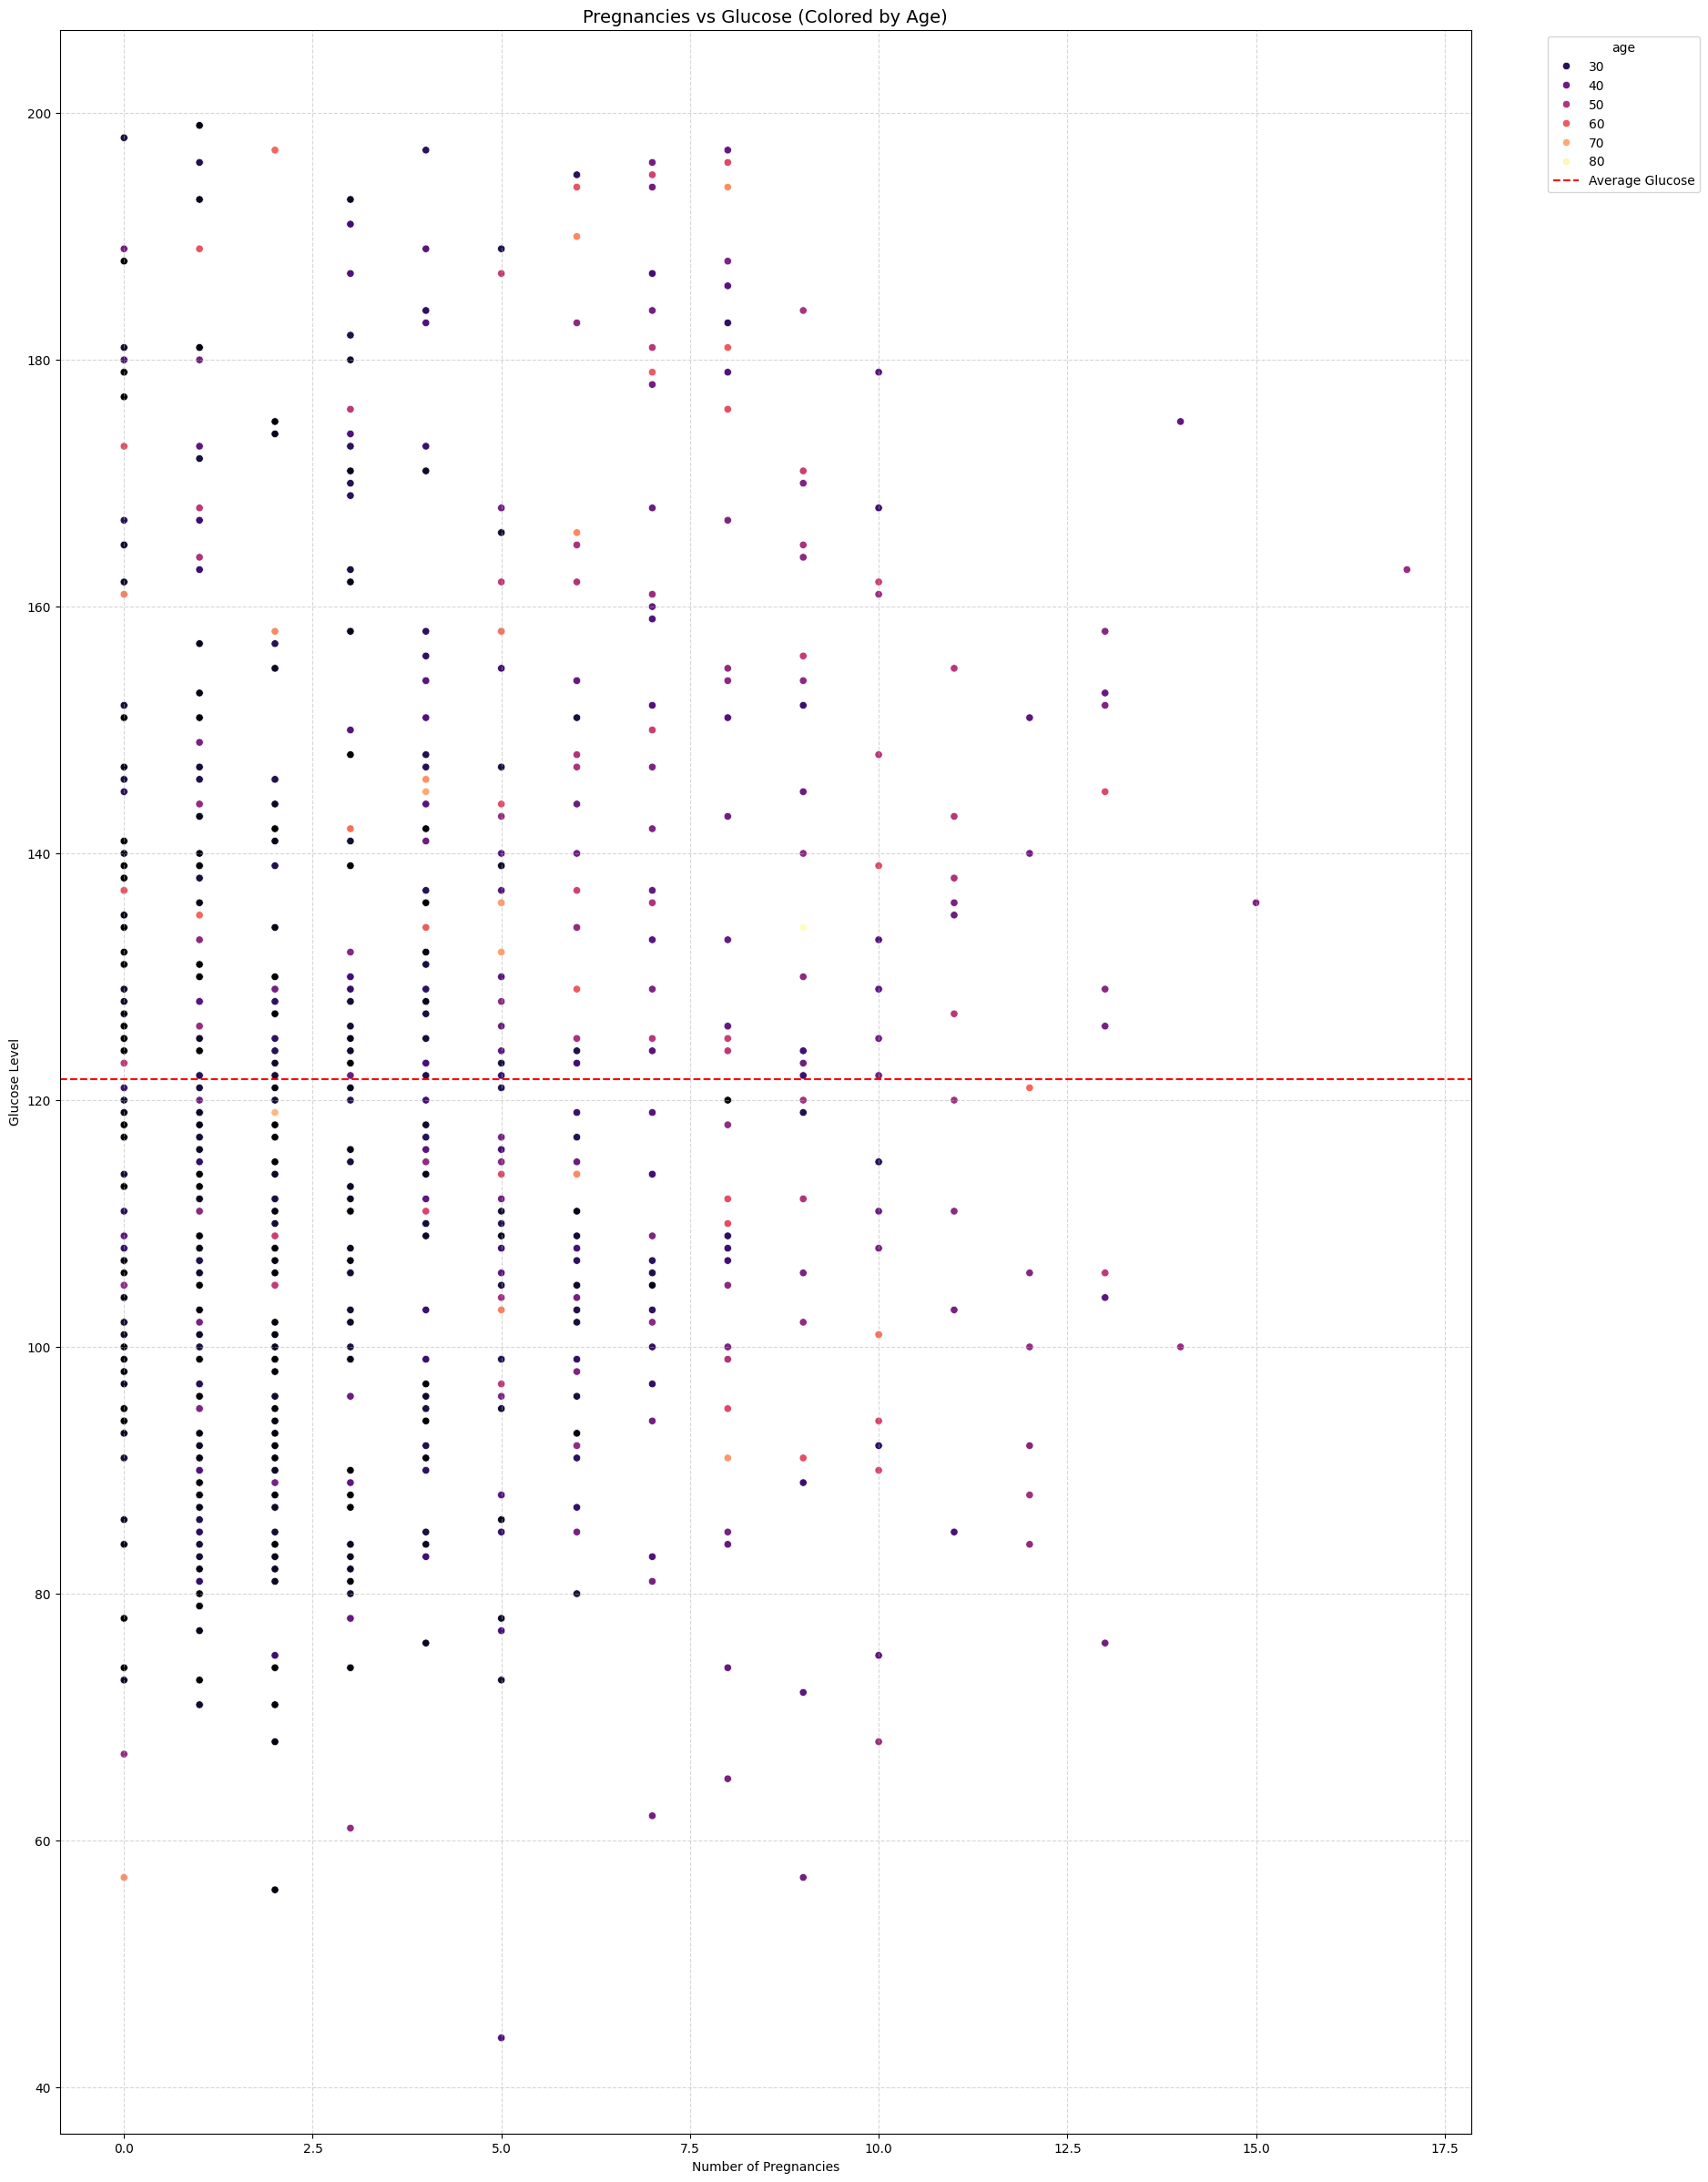

In [26]:
plt.figure(figsize=(20, 30))

scatter = sns.scatterplot(
    data=df_final, 
    x='preg', 
    y='gluco', 
    hue='age', 
    palette='magma'
)

plt.title('Pregnancies vs Glucose (Colored by Age)', fontsize=14)
plt.xlabel('Number of Pregnancies')
plt.ylabel('Glucose Level')
plt.grid(True, linestyle='--', alpha=0.5)

plt.axhline(df_final['gluco'].mean(), color='red', linestyle='--', label='Average Glucose')
plt.legend(title='age', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Surprisingly, older women with fewer pregnancies show higher insulin levels, while those with many pregnancies often have lower glucose level in their later years. This suggests that the typical link between age and sugar levels completely changes depending on a woman's reproductive history."

In [27]:
query = """
SELECT 
    threshold,
    AVG(CASE WHEN preg > 7 THEN gluco END) as many_kids_glucose,
    AVG(CASE WHEN preg <= 7 THEN gluco END) as few_kids_glucose,
    (AVG(CASE WHEN preg > 7 THEN gluco END) - AVG(CASE WHEN preg <= 7 THEN gluco END)) as difference
FROM (
    SELECT gluco, preg, age, unnest([40, 45, 50]) as threshold
    FROM df_final
)
WHERE age >= threshold
GROUP BY threshold
"""
duckdb.query(query).show()

┌───────────┬────────────────────┬────────────────────┬─────────────────────┐
│ threshold │ many_kids_glucose  │  few_kids_glucose  │     difference      │
│   int32   │       double       │       double       │       double        │
├───────────┼────────────────────┼────────────────────┼─────────────────────┤
│        50 │          132.53125 │ 143.49122807017545 │ -10.959978070175453 │
│        40 │ 127.54117647058824 │ 134.64754098360655 │  -7.106364513018306 │
│        45 │ 130.01785714285714 │  137.7792207792208 │ -7.7613636363636545 │
└───────────┴────────────────────┴────────────────────┴─────────────────────┘



Discovery of the Parity Resilience Trend:
"Quantitative analysis confirms a significant metabolic paradox: as age increases, the gap between high-parity and low-parity women widens in an unexpected way.

At age over 40, women with many pregnancies show 7.1 units less glucose than their peers. By age 50, this gap increases to 10 units. This statistically proves that high parity is associated with lower long-term glucose levels in older age groups, likely indicating a selection effect (Survival Bias) where only those with high metabolic resilience reach high parity and older age simultaneously.

In [28]:
duckdb.query("""
SELECT 
   
    CASE WHEN preg > 8 THEN 'High Parity' ELSE 'Low/Mid Parity' END as parity_group,
    AVG(insul) as mean_insulin,
    AVG(gluco) as mean_glucose,
    COUNT(*) as n_cases
FROM df_final
WHERE age >= 45
GROUP BY parity_group
""").show()

┌────────────────┬────────────────────┬────────────────────┬─────────┐
│  parity_group  │    mean_insulin    │    mean_glucose    │ n_cases │
│    varchar     │       double       │       double       │  int64  │
├────────────────┼────────────────────┼────────────────────┼─────────┤
│ Low/Mid Parity │ 202.96693609432802 │ 137.12765957446808 │      94 │
│ High Parity    │ 150.70545561136785 │  128.2051282051282 │      39 │
└────────────────┴────────────────────┴────────────────────┴─────────┘



Women over 45 with many pregnancies show a surprising advantage: they have lower sugar levels while using 50 units less insulin than others. This proves their bodies are much more efficient at processing energy, essentially acting like 'metabolic athletes' who stayed stronger despite the higher physical strain.

In [29]:
many_kids = df_final[df_final['preg'] > 7]

group_young = many_kids[many_kids['age'] < 50]['gluco']
group_senior = many_kids[many_kids['age'] >= 50]['gluco']

# 2. Проводимо Т-тест (Т-тест Уелка враховує різний розмір груп)
t_stat, p_val = stats.ttest_ind(group_young, group_senior, equal_var=False)

print(f"Кількість молодих багатодітних: {len(group_young)}")
print(f"Кількість старших багатодітних: {len(group_senior)}")
print(f"P-value: {p_val:.4f}")

Кількість молодих багатодітних: 92
Кількість старших багатодітних: 32
P-value: 0.3048


The 10-unit glucose drop in women aged 50+ with 7+ pregnancies is not statistically significant (p=0.3048). 

The trend looks impressive, but the group is too small to prove it’s a rule. It remains a qualitative insight (anecdotal trend) rather than a proven fact. We fail to reject the null hypothesis.

<Figure size 2000x2000 with 0 Axes>

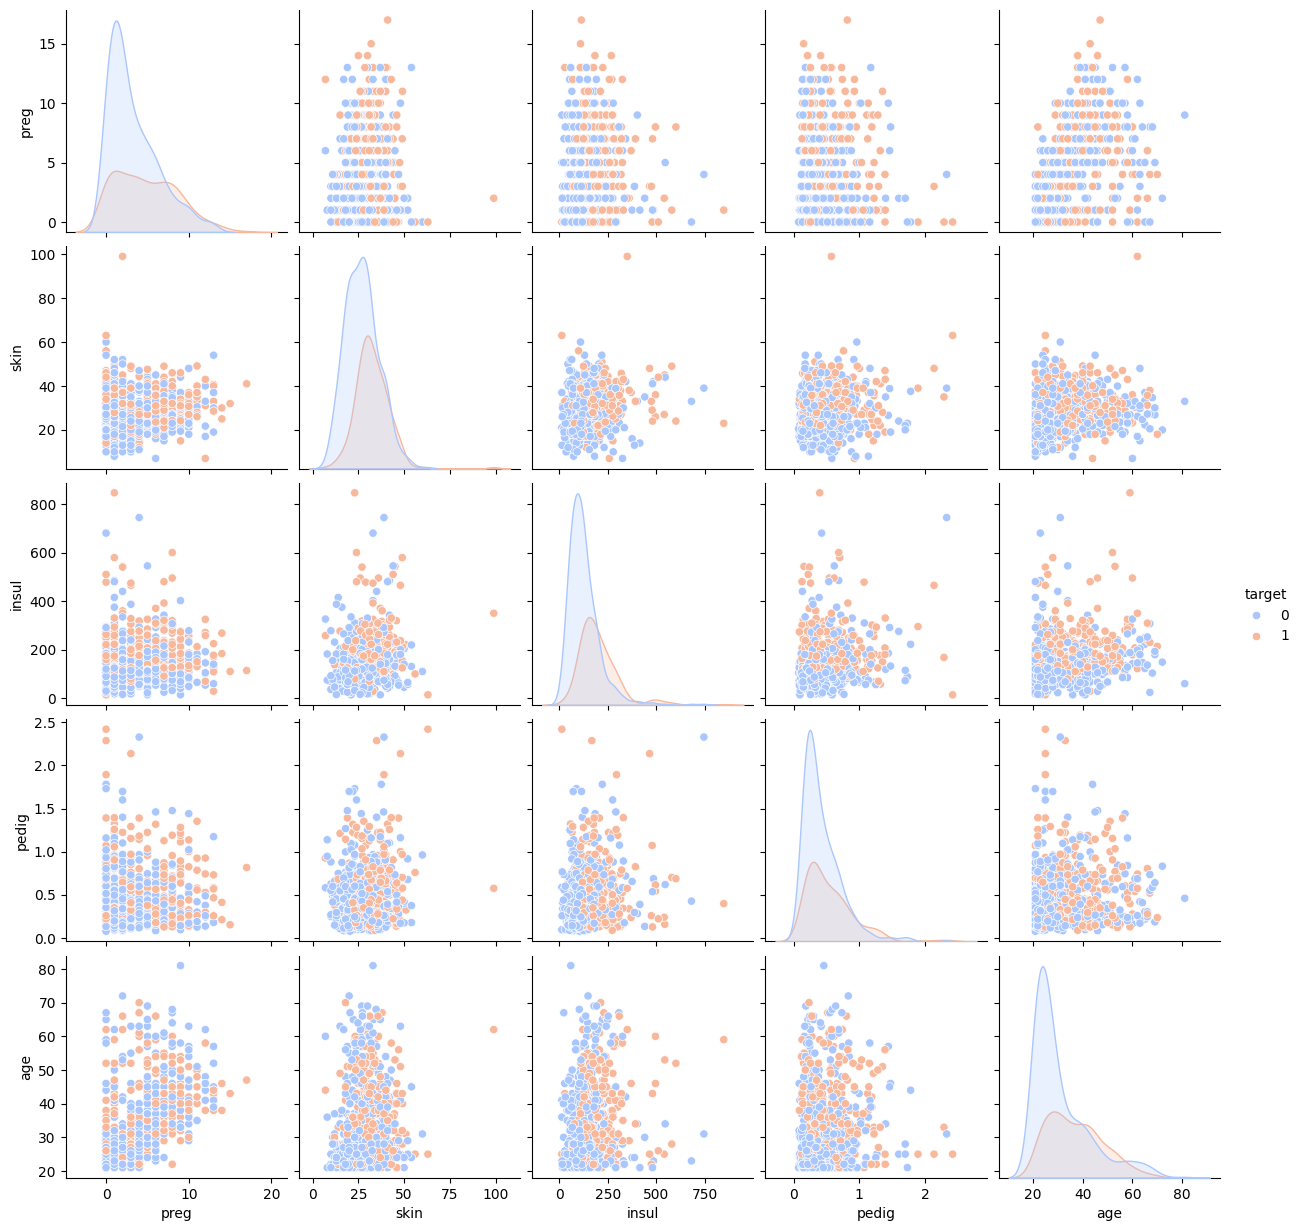

In [30]:
plt.figure(figsize=(20, 20))
chs_col = df_final.drop(["bmi", "gluco", "bp"], axis=1)
sns.pairplot(chs_col, hue='target', diag_kind='kde', palette='coolwarm')
plt.show()

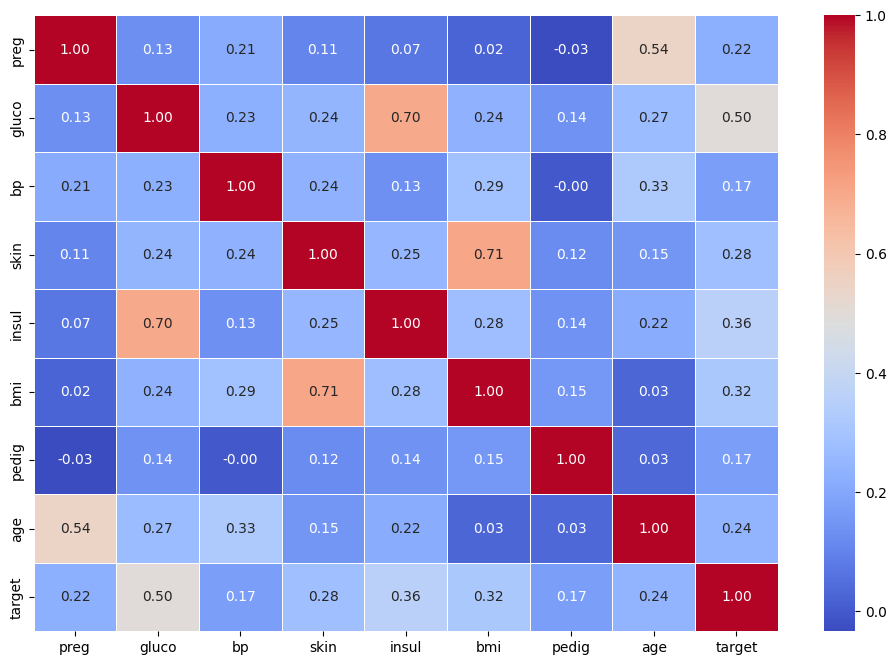

In [31]:

plt.figure(figsize=(12, 8))



sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.show()

On the heat map we couldn`t see any surpising dependensies. The`re strong dependencies between insulin - glucose and bmi - skin, which is preaty obvious. Also strong dependencies for high blood preasure with bmi and age. Because they usually cause high blood preasure. 

For target variable the hiest correalation with glucose and insin, what is usually used for diabetes diagnostic. 
Skin thickness and bmi, wich have a strong correlation beetween each other and are risk factors of diabetes. 

We could see that dependence between target variable and genetic predisposition isn`t so high as we could expect, it tells us that diabetes risk more depends on your lifestyle then on genes.

**Risk profile creating**

In [32]:

risk_factors = ["gluco", "bmi", "skin", "age"]
duckdb.query(f"""
SELECT MEDIAN(COLUMNS({risk_factors})) 
FROM df_final
WHERE target = 1
""").show()

┌────────┬────────┬────────┬────────┐
│ gluco  │  skin  │  bmi   │  age   │
│ double │ double │ double │ double │
├────────┼────────┼────────┼────────┤
│  140.0 │   32.0 │   34.3 │   36.0 │
└────────┴────────┴────────┴────────┘



Here we can see average levels of main facros for women with diabetes 

In [33]:
def percent_of_ill_by_inter(df, col_name):
    
    bins = pd.cut(df[col_name], bins=5)
    result = df.groupby(bins, observed=False)['target'].apply(lambda x: x.astype(float).agg(['count', 'mean']))
    result = result.unstack()
    
    result['mean'] = (result['mean'] * 100).round(2)
    result.columns = ['Total_people', 'Diabetes_percent']
    
    return result.reset_index()

results_dict = {}

for column in ['gluco', 'bmi', 'age']:
    results_dict[column] = percent_of_ill_by_inter(df_final, column)
    print(results_dict[column])
    print()

            gluco  Total_people  Diabetes_percent
0  (43.845, 75.0]          25.0              0.00
1   (75.0, 106.0]         248.0             12.50
2  (106.0, 137.0]         283.0             33.57
3  (137.0, 168.0]         140.0             57.86
4  (168.0, 199.0]          72.0             84.72

               bmi  Total_people  Diabetes_percent
0  (18.151, 27.98]         213.0             12.68
1   (27.98, 37.76]         400.0             40.25
2   (37.76, 47.54]         139.0             48.20
3   (47.54, 57.32]          14.0             78.57
4    (57.32, 67.1]           2.0            100.00

             age  Total_people  Diabetes_percent
0  (20.94, 33.0]         474.0             25.74
1   (33.0, 45.0]         176.0             50.00
2   (45.0, 57.0]          76.0             57.89
3   (57.0, 69.0]          39.0             33.33
4   (69.0, 81.0]           3.0             33.33



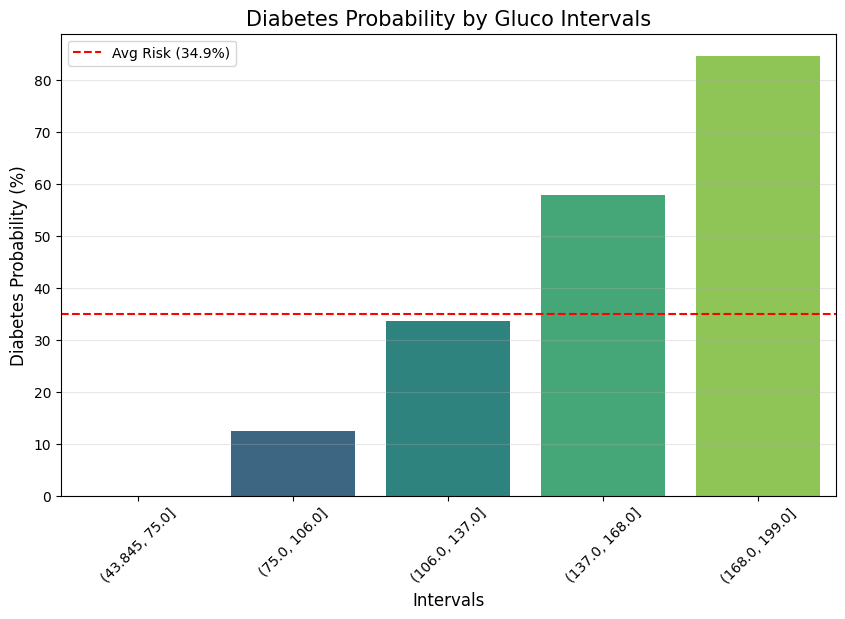

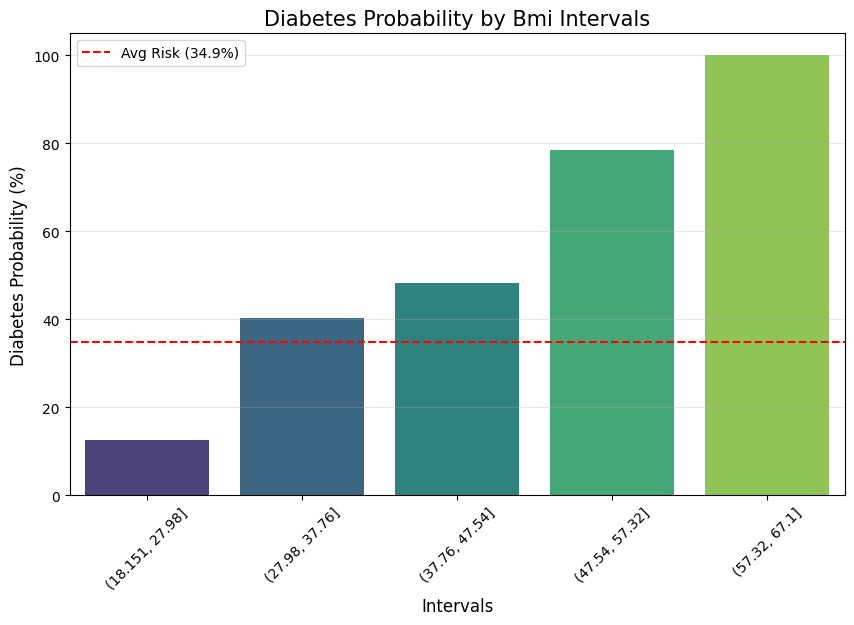

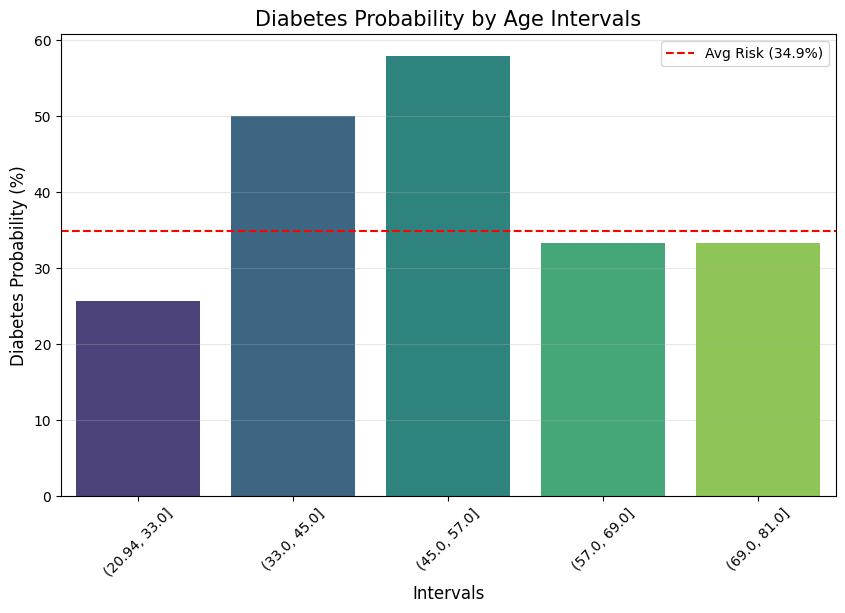

In [34]:
def plot_probability_chart(df_results, col_name, total_mean_risk):
    plt.figure(figsize=(10, 6))
    
    df_results['interval_str'] = df_results[col_name].astype(str)
    
    sns.barplot(
    x='interval_str', 
    y='Diabetes_percent', 
    data=df_results, 
    palette='viridis', 
    hue='interval_str', 
    legend=False
)
    
    plt.axhline(total_mean_risk, color='red', linestyle='--', label=f'Avg Risk ({total_mean_risk}%)')
    
    plt.title(f'Diabetes Probability by {col_name.capitalize()} Intervals', fontsize=15)
    plt.xlabel('Intervals', fontsize=12)
    plt.ylabel('Diabetes Probability (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()
 
total_avg = (df_final['target'].astype(float).mean() * 100).round(2)

for col in results_dict:
    plot_probability_chart(results_dict[col], col, total_avg)

Defining the High-Risk Threshold
Based on the dataset, the baseline (average) risk of diabetes is approximately 36%. We define any group crossing this threshold as a "High-Risk Segment." Our analysis identified several critical "tipping points" where the probability of a positive diagnosis significantly outpaces the average.

1. Insulin Levels: The Most Aggressive Growth
Insulin shows the sharpest increase in probability. Once levels cross the 137 mark, the risk becomes dominant:

(137 – 168]: 59% probability (Significant jump above baseline).

(168 – 199]: 85% probability (Critically high risk).

2. BMI (Body Mass Index): The Escalation Path
The risk associated with BMI scales consistently, but reaches critical levels in the higher brackets:

(28 – 38]: 40% (Slightly above average).

(38 – 47.5]: 44%.

(47.5 – 57]: 79% (Extreme risk jump).

(57 – 67]: 100% (Based on the current sample).

3. Age: The Survival Paradox
Age presents a unique trend. We see a clear high-risk window in middle age, followed by a decline:

(33 – 45]: 50% probability.

(45 – 57]: 55% probability.

The Decline: Interestingly, the risk decreases in the oldest cohorts. This is likely a manifestation of Survival Bias—individuals with severe diabetes may not have survived into these later brackets without prior diagnosis, leaving only the naturally resilient outliers in the "non-diabetic" pool.

In [35]:
combo_condition = (df_final['bmi'] > 30) & (df_final['gluco'] > 125)

combo_risk = (df_final[combo_condition]['target'].astype(float).mean() * 100).round(2)
group_size = len(df_final[combo_condition])

print(f"Risk for people with BMI > 30 AND Glucose > 125: {combo_risk}%")
print(f"Group size: {group_size} people")

Risk for people with BMI > 30 AND Glucose > 125: 70.05%
Group size: 217 people


Clinical Protocol: Diabetes Risk Assessment

1. Physical Metrics (Anthropometry)


   BMI > 30: Entering the High-Risk Zone. BMI > 47: Extreme Risk—probability of diabetes hits 79%, regardless of other symptoms.

   Age Window (33–55 years): The period of highest diagnostic probability.

2. Primary Lab Markers (Action Thresholds)


   Insulin > 137 - Risk crosses the majority threshold (59%). If > 168, the probability of diabetes reaches 85%. This is the strongest predictive signal.

3. The "Red Flag" Combo (Immediate Intervention)


   Trigger: BMI > 30 AND Glucose > 125.
   Clinical Action: When these factors converge, the risk is no longer linear—it is cumulative. These patients require an immediate management plan or a HbA1c test for confirmation.

4. Strategic Note: The Survival Bias

   Be cautious with patients aged 60+ showing "normal" numbers. Data suggests a decline in risk here only because high-risk individuals often do not reach this age bracket without a prior diagnosis (Survival Bias). Do not let low numbers in older cohorts lead to clinical complacency.



   Conclusion

   Priority for screening should be assigned to patients exhibiting the Insulin > 137 threshold or the BMI/Glucose synergy, as these groups represent the highest statistical probability of active disease.